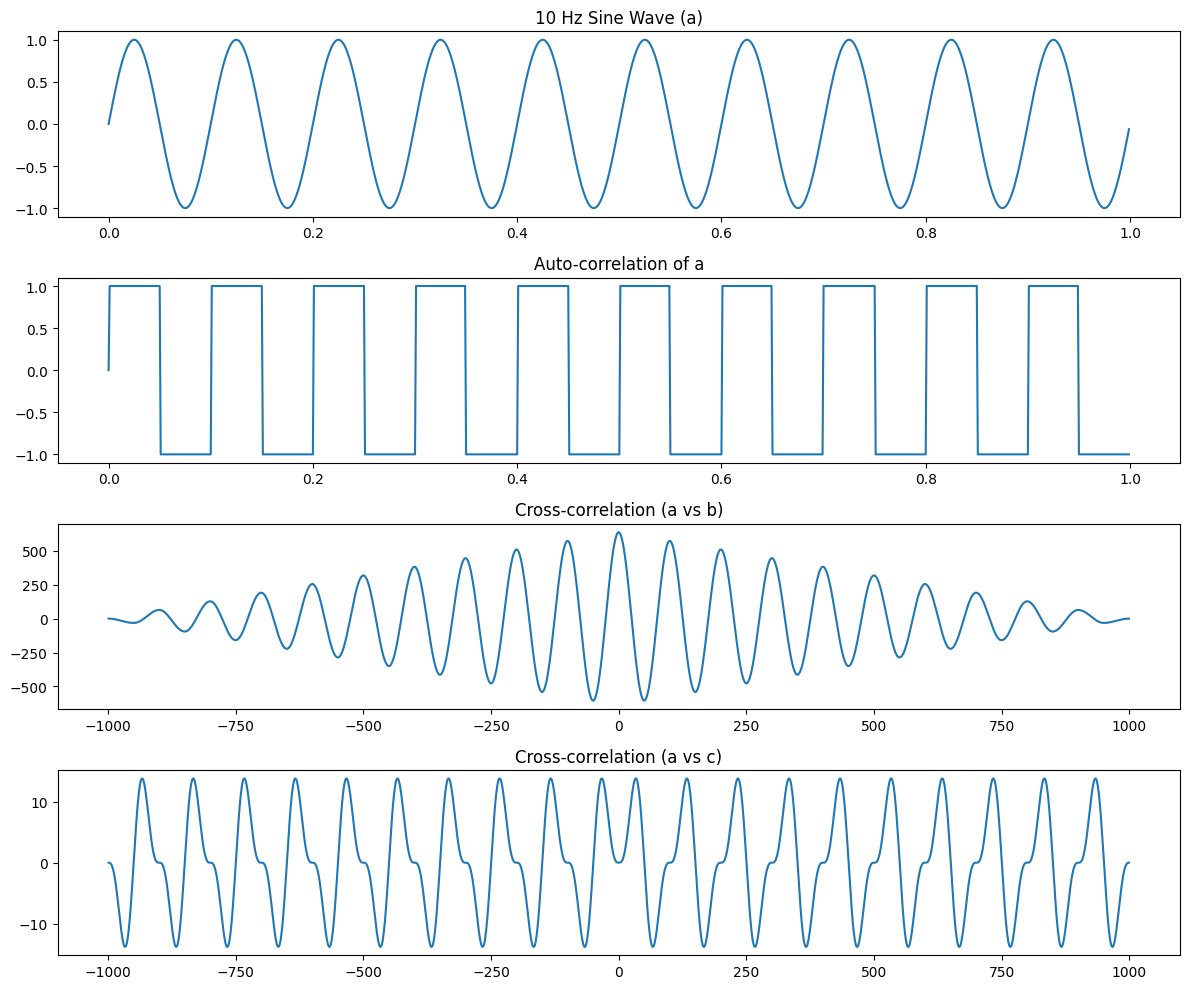

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Manual convolution function
# -----------------------------
def convolve(x, h):
    len_x = len(x)
    len_h = len(h)
    len_y = len_x + len_h - 1
    y = np.zeros(len_y)

    for i in range(len_y):
        for k in range(len_x):
            if (i - k >= 0 and i - k < len_h):
                y[i] += x[k] * h[i - k]
    return y

# -----------------------------
# Time axis
# -----------------------------
fs = 1000   # sampling frequency
t = np.arange(0, 1, 1/fs)

# -----------------------------
# Signals
# -----------------------------
# a) 10 Hz sine
a = np.sin(2 * np.pi * 10 * t)

# b) 10 Hz square wave
b = np.sign(np.sin(2 * np.pi * 10 * t))

# c) 20 Hz sine
c = np.sin(2 * np.pi * 20 * t)

# -----------------------------
# Correlations using convolution
# -----------------------------

# Auto-correlation of a
auto_a = convolve(a, np.flip(a))

# Cross-correlation a & b
cross_ab = convolve(a, np.flip(b))

# Cross-correlation a & c
cross_ac = convolve(a, np.flip(c))

# Lag axis
lags = np.arange(-len(a)+1, len(a))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(t, a)
plt.title("10 Hz Sine Wave (a)")

plt.subplot(4,1,2)
plt.plot(t, b)
plt.title("Auto-correlation of a")

plt.subplot(4,1,3)
plt.plot(lags, cross_ab)
plt.title("Cross-correlation (a vs b)")

plt.subplot(4,1,4)
plt.plot(lags, cross_ac)
plt.title("Cross-correlation (a vs c)")

plt.tight_layout()
plt.show()